# PROJET FIL ROUGE
##### Modèle de Machine Learning sur les Jeux Olympiques de 2028 à Los Angeles 

---

### **NETTOYAGE ET PRÉPARATION DES DONNÉES**

##### IMPORT DE L'ENVIRONNEMENT DE TRAVAIL

In [9]:
import pandas as pd

df = pd.read_csv("olympics_dataset.csv")

##### VISUALISATION DES DONNÉES

In [10]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


In [11]:
df.shape

(252565, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252565 entries, 0 to 252564
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   player_id  252565 non-null  int64 
 1   Name       252565 non-null  object
 2   Sex        252565 non-null  object
 3   Team       252565 non-null  object
 4   NOC        252565 non-null  object
 5   Year       252565 non-null  int64 
 6   Season     252565 non-null  object
 7   City       252565 non-null  object
 8   Sport      252565 non-null  object
 9   Event      252565 non-null  object
 10  Medal      252565 non-null  object
dtypes: int64(2), object(9)
memory usage: 21.2+ MB


##### VÉRIFICATION DE LA QUALITÉ DES DONNÉES 

In [13]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id    0
Name         0
Sex          0
Team         0
NOC          0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

In [14]:
df.duplicated().sum() # vérification des doublons dans le dataset

0

In [15]:
df['player_id'].nunique()

235903

In [16]:
df['Season'].unique() # vérification des colonnes à potentiellement supprimer 

array(['Summer'], dtype=object)

In [17]:
df = df.drop(['Season'], axis=1) # suppression de la colonne Season car 1 seule valeur unique

In [18]:
df["NOC"].nunique() # vérification de la pertinence de la colonne par rapport à Team


234

In [19]:
df["Team"].nunique() # vérification de la pertinence de la colonne par rapport à NOC

1193

##### VALEURS ABERRANTES 

In [20]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


Year    Axes(0.125,0.747241;0.110714x0.132759)
dtype: object

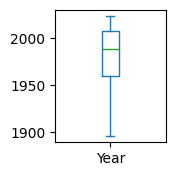

In [21]:
# Visualisation de la seule colonne numérique

df['Year'].plot(
    kind="box",
    subplots=True,
    layout=(5, 6),
    figsize=(10, 10)
)

##### IMPORT DES VALEURS D'ÂGE 

In [22]:
df_info_athlete = pd.read_csv("olympics_age.csv", sep=",")

In [23]:
df_info_athlete = pd.read_csv("olympics_age.csv", sep=",")
display(df_info_athlete.head())

,name,sex,age,medal,year,season,noc,country
0,Dijiang,Male,24.0,NaN,1992,summer,CHN,China
1,Lamusi,Male,23.0,NaN,2012,summer,CHN,China
2,unnar Nielsen Aaby,Male,24.0,NaN,1920,summer,DEN,Denmark
3,dgar Lindenau Aabye,Male,34.0,Gold,1900,summer,DEN,Denmark
4,hristine Jacoba Aaftink,Female,21.0,NaN,1988,winter,NED,Netherlands


In [24]:
df_info_athlete.shape

(300714, 8)

In [25]:
df_info_athlete.isna().sum() # vérification des valeurs nulles dans le dataset 

# On ne peut donc pas merge aussi avec les médailles 

name            0
sex             0
age          9474
medal      256170
year            0
season          0
noc             5
country         5
dtype: int64

In [26]:
# Les NaN de age représente 3.15 % du volume de ce dataset donc on les supprime

df_info_athlete = df_info_athlete.dropna(subset=["age"])

In [27]:
df_summer = df_info_athlete[df_info_athlete['season'] == 'summer']

drop = ['country', 'season']
df_age = df_summer.drop(columns=drop)

# Afficher le résultat pour vérifier
display(df_age.head())

,name,sex,age,medal,year,noc
0,Dijiang,Male,24.0,NaN,1992,CHN
1,Lamusi,Male,23.0,NaN,2012,CHN
2,unnar Nielsen Aaby,Male,24.0,NaN,1920,DEN
3,dgar Lindenau Aabye,Male,34.0,Gold,1900,DEN
26,"ornelia ""Cor"" Aalten (-Strannood)",Female,18.0,NaN,1932,NED


In [28]:
df_age["age"] = df_age["age"].round(0).astype(int)

In [29]:
df_age['sex'] = df_age['sex'].replace({'Male': 'M', 'Female': 'F'})

Étape 1 — Nettoyer les noms dans les deux datasets

In [30]:
import unidecode

def clean_name(x):
    x = unidecode.unidecode(x)          # enlever accents
    x = x.lower().strip()               # enlever les espaces avant et après + tout mettre en minuscule
    x = x.replace("-", " ")             # enlever les tirets
    x = " ".join(x.split())             # normaliser espaces
    return x

# Appliquer aux deux datasets df_age et df

df["clean_name"] = df["Name"].apply(clean_name)
df_age["clean_name"] = df_age["name"].apply(clean_name)

Étape 2 — Extraire le nom de famille proprement

In [31]:
# Etraire les noms pour les merger ensuite 

df["last_name"] = df["clean_name"].str.split().str[-1]
df_age["last_name"] = df_age["clean_name"].str.split().str[-1]

Étape 3 — Merge souple (sans Medal)

In [32]:
df = df.merge(
    df_age.rename(columns={
        "last_name": "last_name",
        "sex": "Sex",
        "noc": "NOC",
        "year": "Year",
        "age": "Age"
    })[["last_name", "Sex", "NOC", "Year", "Age"]],
    on=["last_name", "Sex", "NOC", "Year"],
    how="left"
)


In [33]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal,clean_name,last_name,Age
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,No medal,a dijiang,dijiang,24.0
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,No medal,a lamusi,lamusi,23.0
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,No medal,gunnar aaby,aaby,24.0
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,edgar aabye,aabye,34.0
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,No medal,cornelia ( strannood),strannood),18.0


In [34]:
1 - df["Age"].isna().mean()

# 94.06 % de matching réussi

0.9406465717929513

In [35]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

# Les valeurs nulles des âges représentent 6%. On attend de filtrer les années à > 1960, avant de prendre une décision.

player_id         0
Name              0
Sex               0
Team              0
NOC               0
Year              0
City              0
Sport             0
Event             0
Medal             0
clean_name        0
last_name         0
Age           38116
dtype: int64

##### ENCODAGE DES DONNÉES (Sex, Medal)

In [36]:
df['Sex'].unique()

array(['M', 'F'], dtype=object)

In [37]:
df["Sex_encoded"] = df["Sex"].map({"M": 1, "F": 0}) # encodage de Sex pour faciliter la création des champs 

In [38]:
df["Medal"].unique()

array(['No medal', 'Gold', 'Bronze', 'Silver'], dtype=object)

In [39]:
# Normalisation de Medal

df["Medal"] = df["Medal"].str.strip().str.lower()
df["Medal"] = df["Medal"].fillna("no medal")

In [40]:
# Encodage réaliste des médailles

df["Medal_score"] = df["Medal"].map({
    "no medal": 0,
    "bronze": 1,
    "silver": 2,
    "gold": 3
})

In [41]:
df["Medal_score"].value_counts(dropna=False)

Medal_score
0    547728
3     34249
2     30261
1     29949
Name: count, dtype: int64

##### CRÉATION DE NOUVEAUX CHAMPS 

1. FEATURES ATHLÈTES

In [42]:
# Indicateur binaire : l’athlète a-t-il gagné une médaille ?
df["has_medal"] = (df["Medal_score"] > 0).astype(int)

In [43]:
# Durée de carrière olympique (première → dernière participation)

'''df["histo_athlete_years"] = (
    df.groupby("player_id")["Year"]
      .transform(lambda x: x.max() - x.min())
)'''

'df["histo_athlete_years"] = (\n    df.groupby("player_id")["Year"]\n      .transform(lambda x: x.max() - x.min())\n)'

In [44]:
# Nombre total de participations par athlète

df["particip_athlete"] = (
    df.groupby("Name")["Year"]
      .transform("count")
)

In [45]:
# Nombre d’équipes distinctes par athlète, pays, année

df["nb_team"] = (
    df.groupby(["Name", "NOC", "Year"])["Team"]
      .transform("nunique")
)

In [46]:
# Score médaille total par athlète

df["medal_score_athlete_total"] = (
    df.groupby("player_id")["Medal_score"]
      .transform("sum")
)

In [47]:
# Nombre total de médailles par athlète

df["nb_medal_athlete"] = (
    df.groupby("player_id")["has_medal"]
      .transform("sum")
)

In [48]:
# Nombre de médailles cumulées AVANT l'édition actuelle : cela permet d'avoir le chemin de médaille par athlète au fil des années de participation

df["evol_medal_athlete"] = (
    df.groupby("player_id")["has_medal"]
      .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

2. FEATURES PAYS (NOC)

In [49]:
# Nombre total de participations par pays (années distinctes)

df["particip_pays"] = (
    df.groupby("NOC")["Year"]
      .transform("nunique")
)

In [50]:
# Nombre d’athlètes distincts par pays et année

df["nb_athlete_country"] = (
    df.groupby(["NOC", "Year"])["Name"]
      .transform("nunique")
)

In [51]:
# Nombre total de sports distincts par pays

df["nb_sport_country"] = (
    df.groupby(["NOC", "Year"])["Sport"]
      .transform("nunique")
)

In [52]:
# Score médaille total par pays

df["medal_score_country_total"] = (
    df.groupby(["NOC", "Year"])["Medal_score"]
      .transform("sum")
)

In [53]:
# Nombre total de médailles par pays

df["nb_medal_country"] = (
    df.groupby("NOC")["has_medal"]
      .transform("sum")
)

In [54]:
# Nombre de médailles cumulées : : cela permet d'avoir le chemin de médaille par athlète au fil des années de participation
# Pour chaque pays et chaque année, on calcule combien de médailles il avait AVANT cette année.

country_yearly = (
    df.groupby(["NOC", "Year"])[["has_medal", "Medal_score"]]
      .sum()
      .sort_values(["NOC", "Year"])
      .reset_index()
)

country_yearly["evol_medal_country"] = (
    country_yearly.groupby("NOC")["has_medal"]
    .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

In [55]:
df = df.merge(
    country_yearly[["NOC", "Year", "evol_medal_country"]],
    on=["NOC", "Year"],
    how="left"
)

In [56]:
# Calcul du Ratio médaille / pays 

country_yearly = (
    df.groupby(["NOC", "Year"])
      .agg(
          nb_athletes=("player_id", "nunique"),
          nb_medals=("has_medal", "sum")
      )
      .reset_index()
)

In [57]:
# Taux de médaille par pays et par année

country_yearly["medal_rate"] = (
    country_yearly["nb_medals"] / country_yearly["nb_athletes"]
)

# Ce taux varie entre 0 et 1
# Il capture l’efficacité du pays

In [58]:
# Ratio : Athlètes moyens / Taux de médaille

country_yearly["athlete_medal_ratio"] = (
    country_yearly["nb_athletes"] / (country_yearly["medal_rate"] + 1e-6)
)

# Ajout de 1e-6 pour éviter une division par zéro quand un pays n’a aucune médaille une année.

In [59]:
df = df.merge(
    country_yearly[[
        "NOC", "Year",
        "nb_athletes",
        "nb_medals",
        "medal_rate",
        "athlete_medal_ratio"
    ]],
    on=["NOC", "Year"],
    how="left"
)

5. PARTIE HÔTE

In [60]:
host_countries = {
    1896: "GRE",
    1900: "FRA",
    1904: "USA",
    1908: "GBR",
    1912: "SWE",
    1920: "BEL",
    1924: "FRA",
    1928: "NED",
    1932: "USA",
    1936: "GER",
    1948: "GBR",
    1952: "FIN",
    1956: "AUS",
    1960: "ITA",
    1964: "JPN",
    1968: "MEX",
    1972: "GER",
    1976: "CAN",
    1980: "URS",
    1984: "USA",
    1988: "KOR",
    1992: "ESP",
    1996: "USA",
    2000: "AUS",
    2004: "GRE",
    2008: "CHN",
    2012: "GBR",
    2016: "BRA",
    2020: "JPN",
    2024: "FRA",
}

In [61]:
host_df = pd.DataFrame.from_dict(
    host_countries,
    orient="index",
    columns=["host_NOC"]
)
host_df.index.name = "Year"

In [62]:
df = df.merge(host_df, on="Year", how="left")

In [63]:
df["is_host_country"] = (df["NOC"] == df["host_NOC"]).astype(int)

In [64]:
df["host_NOC"] = df["host_NOC"].fillna("UNK")

6. FILTRE RECENT : conserver des athlètes potentiellement toujours en activité

In [65]:
from datetime import datetime

In [66]:
current_year = datetime.now().year # définir current_year

In [67]:
# Calculer l’année de première participation de chaque athlète

df["first_year_athlete"] = df.groupby("player_id")["Year"].transform("min")
df["years_since_first"] = current_year - df["first_year_athlete"]

In [68]:
# Créer un champ pour identifier les athlètes encore “récents”, qui ont un nombre d'année jusqu'à aujourd'hui inférieur à 20.

df["recent_athlete"] = (df["years_since_first"] <= 20).astype(int)

##### VÉRIFICATION DES CHAMPS CRÉÉS

In [69]:
print(df.shape)
print(df.columns)

(642187, 36)
Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'clean_name', 'last_name', 'Age', 'Sex_encoded',
       'Medal_score', 'has_medal', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'evol_medal_athlete',
       'particip_pays', 'nb_athlete_country', 'nb_sport_country',
       'medal_score_country_total', 'nb_medal_country', 'evol_medal_country',
       'nb_athletes', 'nb_medals', 'medal_rate', 'athlete_medal_ratio',
       'host_NOC', 'is_host_country', 'first_year_athlete',
       'years_since_first', 'recent_athlete'],
      dtype='object')


In [70]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal,...,evol_medal_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,host_NOC,is_host_country,first_year_athlete,years_since_first,recent_athlete
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,no medal,...,326.0,394,330,0.837563,470.411560,ESP,0,1992,34,0
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,no medal,...,2066.0,479,290,0.605428,791.174555,GBR,0,2012,14,1
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,no medal,...,635.0,246,336,1.365854,180.107011,BEL,0,1920,106,0
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,gold,...,39.0,36,27,0.750000,47.999936,FRA,0,1900,126,0
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,no medal,...,410.0,80,30,0.375000,213.332764,USA,0,1932,94,0


In [71]:
df.shape

(642187, 36)

##### FILTRES 

In [72]:
df = df[df["Age"] < 45]

In [73]:
df = df[df["Year"] > 1960]

In [74]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id                    0
Name                         0
Sex                          0
Team                         0
NOC                          0
Year                         0
City                         0
Sport                        0
Event                        0
Medal                        0
clean_name                   0
last_name                    0
Age                          0
Sex_encoded                  0
Medal_score                  0
has_medal                    0
particip_athlete             0
nb_team                      0
medal_score_athlete_total    0
nb_medal_athlete             0
evol_medal_athlete           0
particip_pays                0
nb_athlete_country           0
nb_sport_country             0
medal_score_country_total    0
nb_medal_country             0
evol_medal_country           0
nb_athletes                  0
nb_medals                    0
medal_rate                   0
athlete_medal_ratio          0
host_NOC                     0
is_host_

##### VIF : GESTION DES FEATURES REDONDANTES (détecter la multicolinéarité entre les variables quantitatives)

In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [76]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'clean_name', 'last_name', 'Age', 'Sex_encoded',
       'Medal_score', 'has_medal', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'evol_medal_athlete',
       'particip_pays', 'nb_athlete_country', 'nb_sport_country',
       'medal_score_country_total', 'nb_medal_country', 'evol_medal_country',
       'nb_athletes', 'nb_medals', 'medal_rate', 'athlete_medal_ratio',
       'host_NOC', 'is_host_country', 'first_year_athlete',
       'years_since_first', 'recent_athlete'],
      dtype='object')

In [77]:
# Sélection des colonnes et suppression feature par feature selon les résultats du VIF

cols_vif = ['Year', 'Sex_encoded', 'Medal_score', 'has_medal',
       'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_sport_country', 'medal_score_country_total',
       'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'is_host_country',
       'years_since_first', 'recent_athlete']

# Colonnes supprimées : 'first_year_athlete', 'nb_medal_country', 'nb_athlete_country'.

In [78]:
X = df[cols_vif]

In [79]:
# Calcul des VIF  

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]
vif["Precision"] = [1 - 1/VIF(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)


,feature,VIF,Precision
14,nb_medals,309.112264,0.996765
11,medal_score_country_total,268.368987,0.996274
0,Year,165.534907,0.993959
5,nb_team,123.814821,0.991923
10,nb_sport_country,53.445797,0.981289
13,nb_athletes,38.726482,0.974178
15,medal_rate,18.919984,0.947146
9,particip_pays,17.755674,0.943680
7,nb_medal_athlete,15.665636,0.936166
18,years_since_first,15.591565,0.935863


In [80]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'clean_name', 'last_name', 'Age', 'Sex_encoded',
       'Medal_score', 'has_medal', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'evol_medal_athlete',
       'particip_pays', 'nb_athlete_country', 'nb_sport_country',
       'medal_score_country_total', 'nb_medal_country', 'evol_medal_country',
       'nb_athletes', 'nb_medals', 'medal_rate', 'athlete_medal_ratio',
       'host_NOC', 'is_host_country', 'first_year_athlete',
       'years_since_first', 'recent_athlete'],
      dtype='object')

In [81]:
num_cols = ['Year', 'Sex_encoded', 'Medal_score', 'has_medal',
       'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_sport_country', 'medal_score_country_total',
       'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'is_host_country',
       'years_since_first', 'recent_athlete']


quali_cols = ['NOC','Sport', 'Medal', 'host_NOC']

context_cols = ['City', 'player_id', 'Name', 'Sex', 'Team', 'Event']

In [82]:
df_clean = df[['NOC','Sport', 'Medal', 'host_NOC', 'Year', 'Age', 'Sex_encoded', 
               'Medal_score', 'has_medal', 'particip_athlete', 'nb_team', 
               'medal_score_athlete_total', 'nb_medal_athlete', 
               'evol_medal_athlete', 'particip_pays', 'nb_sport_country', 
               'medal_score_country_total', 'evol_medal_country', 'nb_athletes', 
               'nb_medals', 'medal_rate', 'athlete_medal_ratio', 'is_host_country',
               'years_since_first', 'recent_athlete']]

---

### **ANALYSE UNIVARIÉE : Phase CRISP-DM 2 - Compréhension des Données**


##### IMPORT DE L'ENVIRONNEMENT

In [83]:
import numpy as np  #calculS scientifiqueS
import seaborn as sns #visualiser avec des syntaxes simples
import matplotlib.pyplot as plt #visualiser
import sklearn as skl #Creer des modeles de machine learning (pour ce cours, on verra PCA et KMEANS)
from IPython.display import display, Markdown   #afficher
import scipy
import warnings
warnings.filterwarnings('ignore')

##### PREMIÈRES OBSERVATIONS

In [84]:
# Visualisation statistique du dataset générale

df_clean.describe() 

,Year,Age,Sex_encoded,Medal_score,has_medal,particip_athlete,nb_team,medal_score_athlete_total,nb_medal_athlete,evol_medal_athlete,...,nb_sport_country,medal_score_country_total,evol_medal_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,is_host_country,years_since_first,recent_athlete
count,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,...,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,401688.000000,4.016880e+05,401688.000000,401688.000000,401688.000000
mean,1991.114547,23.900136,0.631789,0.280920,0.138247,46.202737,1.008098,2.195204,1.047370,0.450977,...,20.029702,424.975429,1885.894271,330.506991,202.894819,0.452839,3.112780e+06,0.069074,35.087172,0.209635
std,15.820536,5.211021,0.482320,0.765139,0.345159,103.940445,0.091277,9.708686,4.235642,2.376758,...,7.668405,605.236522,3194.444411,203.592230,274.962551,0.499730,1.375673e+07,0.253579,15.846721,0.407049
min,1964.000000,11.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,8.333319e+00,0.000000,2.000000,0.000000
25%,1976.000000,20.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,...,15.000000,36.000000,124.000000,152.000000,21.000000,0.119565,5.921029e+02,0.000000,22.000000,0.000000
50%,1992.000000,23.000000,1.000000,0.000000,0.000000,16.000000,1.000000,0.000000,0.000000,0.000000,...,20.000000,166.000000,807.000000,327.000000,88.000000,0.290598,1.062074e+03,0.000000,34.000000,0.000000
75%,2004.000000,27.000000,1.000000,0.000000,0.000000,56.000000,1.000000,0.000000,0.000000,0.000000,...,26.000000,543.000000,2234.000000,472.000000,265.000000,0.595197,2.201281e+03,0.000000,50.000000,0.000000
max,2024.000000,44.000000,1.000000,3.000000,1.000000,2015.000000,3.000000,111.000000,37.000000,36.000000,...,47.000000,3217.000000,17953.000000,856.000000,1415.000000,3.148148,1.370000e+08,1.000000,130.000000,1.000000


In [85]:
df_clean.shape

(401688, 25)

In [86]:
df_clean.head()

,NOC,Sport,Medal,host_NOC,Year,Age,Sex_encoded,Medal_score,has_medal,particip_athlete,...,nb_sport_country,medal_score_country_total,evol_medal_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,is_host_country,years_since_first,recent_athlete
0,CHN,Basketball,no medal,ESP,1992,24.0,1,0,0,1,...,23,709,326.0,394,330,0.837563,470.411560,0,34,0
1,CHN,Judo,no medal,GBR,2012,23.0,1,0,0,1,...,29,655,2066.0,479,290,0.605428,791.174555,0,14,1
9,FIN,Badminton,no medal,AUS,2000,31.0,1,0,0,1,...,16,16,2082.0,88,7,0.079545,1106.271807,0,26,0
10,FIN,Sailing,no medal,USA,1996,30.0,0,0,0,2,...,15,14,2075.0,105,7,0.066667,1574.976375,0,30,0
11,FIN,Sailing,no medal,AUS,2000,34.0,0,0,0,2,...,16,16,2082.0,88,7,0.079545,1106.271807,0,26,0


##### DISTRIBUTION VARIABLES QUALITATIVES

In [87]:
num_cols = ['Year', 'Sex_encoded', 'Medal_score', 'has_medal',
       'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_sport_country', 'medal_score_country_total',
       'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'is_host_country',
       'years_since_first', 'recent_athlete']


quali_cols = ['NOC','Sport', 'Medal', 'host_NOC']

Medal
no medal    346156
gold         19700
bronze       17922
silver       17910
Name: count, dtype: int64


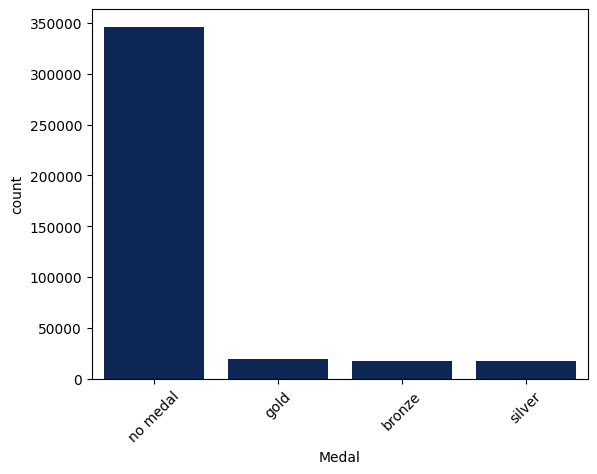

In [88]:
# Visualisation des données qualitatives 

quali_cols = df_clean[['Medal']].columns

for col in quali_cols:
    print(df_clean[col].value_counts())
    sns.countplot(data=df_clean, x=col, color="#032361")
    plt.xticks(rotation=45)
    plt.show()

OBSERVATION : La majorité de la population d'athlètes observée dans ce dataset n'a jamais eu de médaille. 

In [89]:
# Visualisation du nombre de fois que les pays ont été hôte. 

host_counts = (
    df_clean[['Year', 'host_NOC']]
    .drop_duplicates()
    .host_NOC
    .value_counts()
    .reset_index()
)

host_counts.columns = ["host_NOC", "count"]

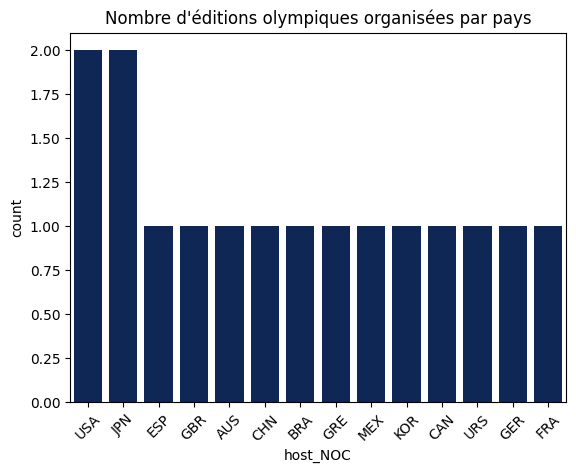

In [90]:
sns.barplot(
    data=host_counts,
    x="host_NOC",
    y="count",
    color="#032361"
)

plt.xticks(rotation=45)
plt.title("Nombre d'éditions olympiques organisées par pays")
plt.show()


OBSERVATION : La majorité des pays hôtes l'ont été 1 fois. Sauf pour les USA ont été hôtes 4 fois depuis 1960, 3 fois pour la France et le Royaume‑Uni, 2 fois pour la Grèce, l'Allemagne, le Japon et l'Australie.

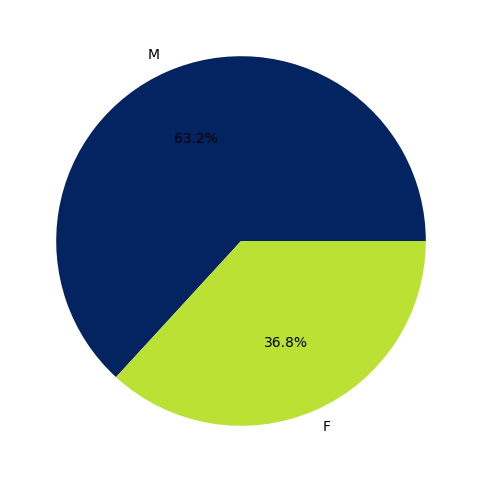

In [91]:
df.Sex.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : La population du dataset est composée de 70% d'hommes et de 30% de femmes.

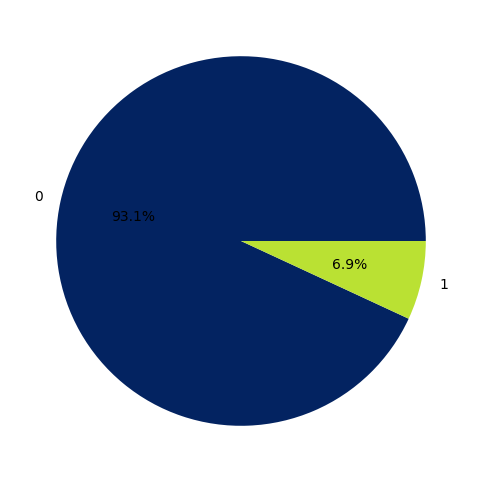

In [92]:
df.is_host_country.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : 93% des pays n'ont jamais été hôtes. 

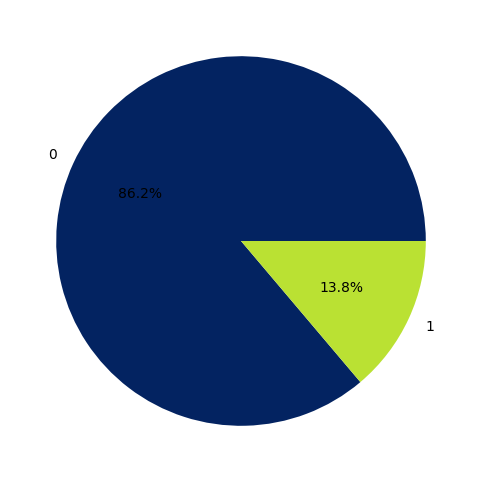

In [93]:
df.has_medal.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : 85% des athlètes n'ont pas eu de médaille.

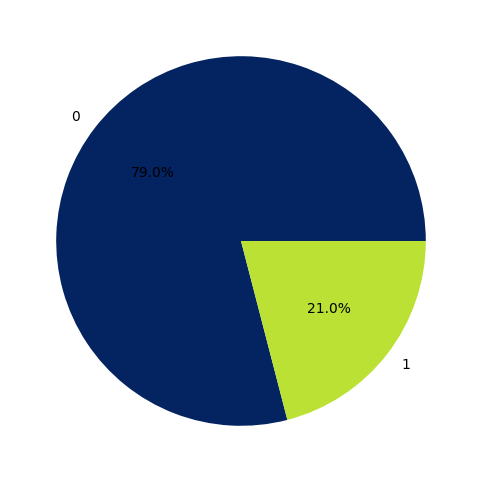

In [94]:
df.recent_athlete.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : 24% des athlètes sont taggés "récents", dans le dataset.

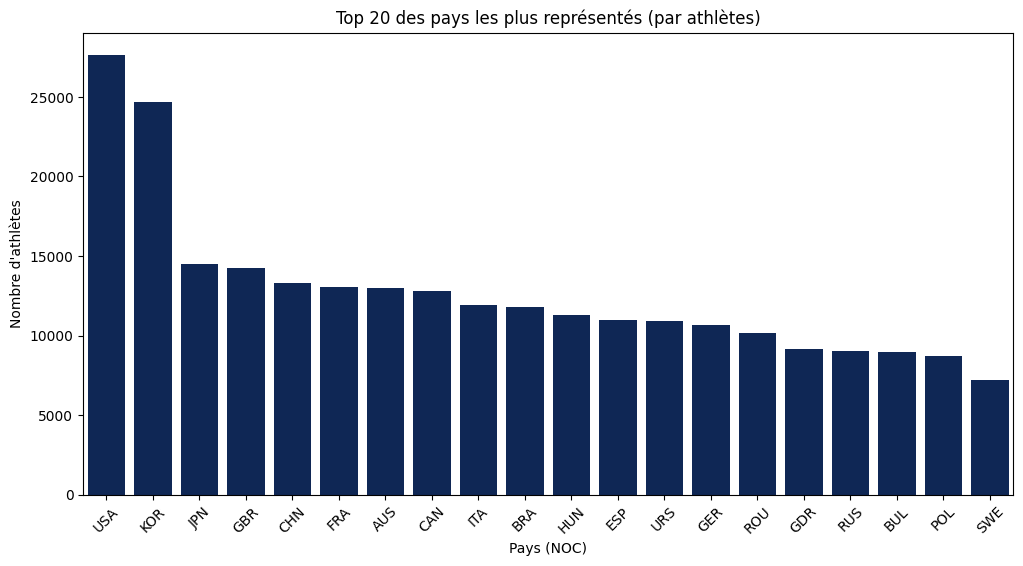

In [95]:
# Top 20 des pays les plus représentés (par athlètes)

top_100_countries = (
    df_clean["NOC"]
    .value_counts()
    .head(100)
    .reset_index()
)

top_100_countries.columns = ["NOC", "nb_athletes"]

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_100_countries.head(20),
    x="NOC",
    y="nb_athletes",
    color="#032361"
)
plt.xticks(rotation=45)
plt.title("Top 20 des pays les plus représentés (par athlètes)")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre d'athlètes")
plt.show()


OBSERVATION : les pays les plus représentés sont les USA, le Royaume-Uni et la France.

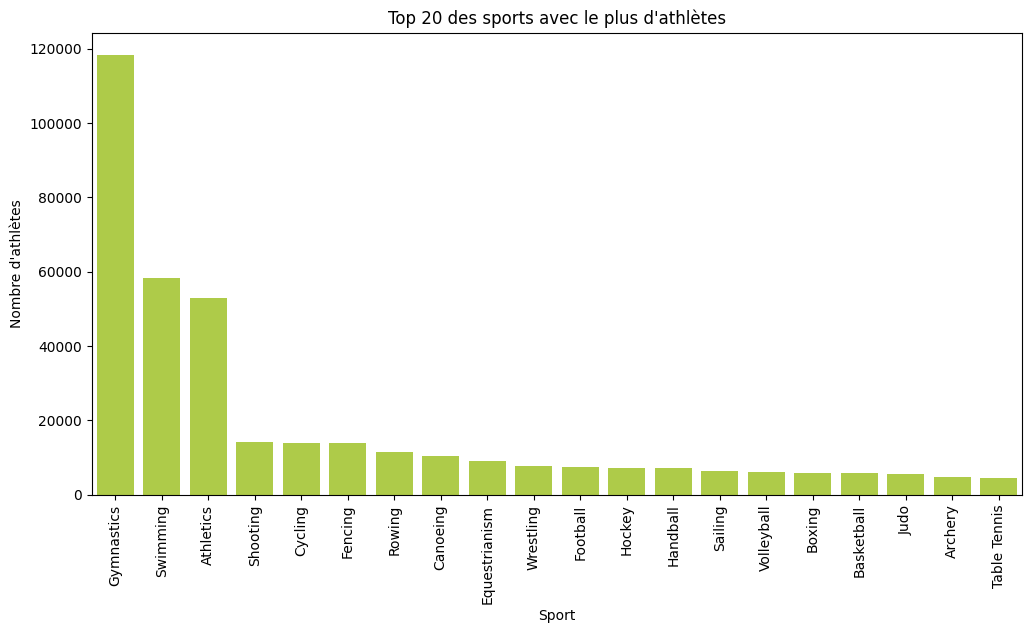

In [96]:
# Top 20 sports les plus représentés

top_100_sports = (
    df_clean["Sport"]
    .value_counts()
    .head(100)
    .reset_index()
)

top_100_sports.columns = ["Sport", "nb_athletes"]

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_100_sports.head(20),
    x="Sport",
    y="nb_athletes",
    color="#bae133"
)
plt.xticks(rotation=90)
plt.title("Top 20 des sports avec le plus d'athlètes")
plt.xlabel("Sport")
plt.ylabel("Nombre d'athlètes")
plt.show()


OBSERVATION : les sports les plus représentés aux JO sont l'Athlétisme, la gymnastique et la natation.

##### DISTRIBUTION VARIABLES NUMÉRIQUES 

Medal_score
0    346156
3     19700
1     17922
2     17910
Name: count, dtype: int64


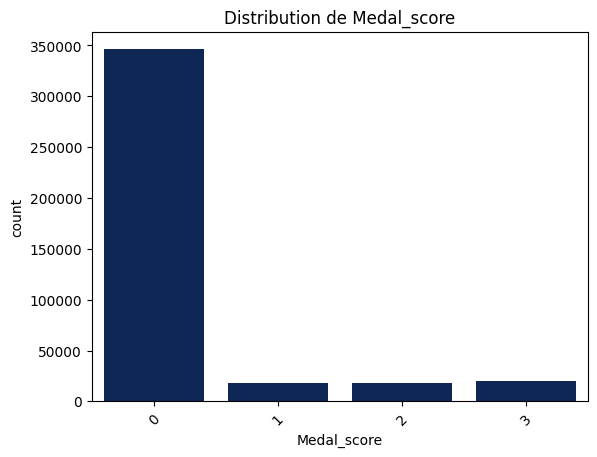

Year
1988    36660
1996    35699
1992    35120
2000    31527
2004    29621
1972    28793
2008    28542
2016    27324
1968    26982
2012    25935
1976    24169
1964    24052
1984    23422
1980    19849
2020     2318
2024     1675
Name: count, dtype: int64


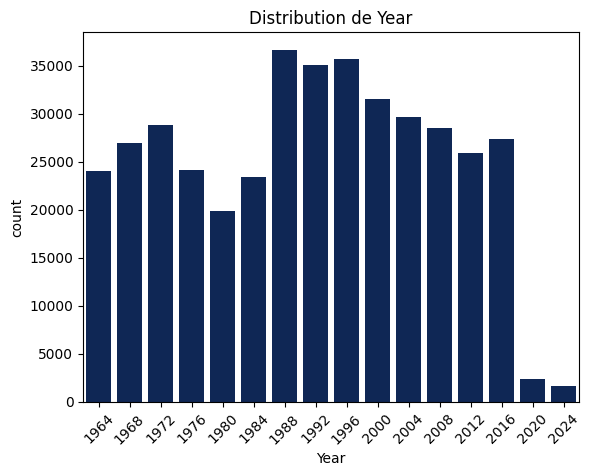

nb_team
1    398495
2      3133
3        60
Name: count, dtype: int64


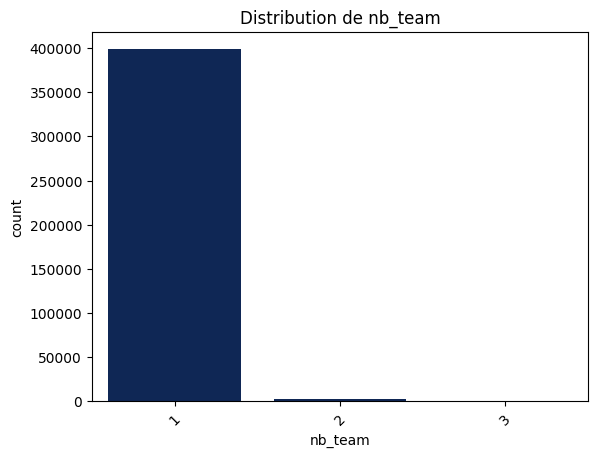

medal_score_athlete_total
0     343019
2       8300
3       6617
6       6017
1       5578
       ...  
34        68
17        34
55        27
82        27
72        24
Name: count, Length: 64, dtype: int64


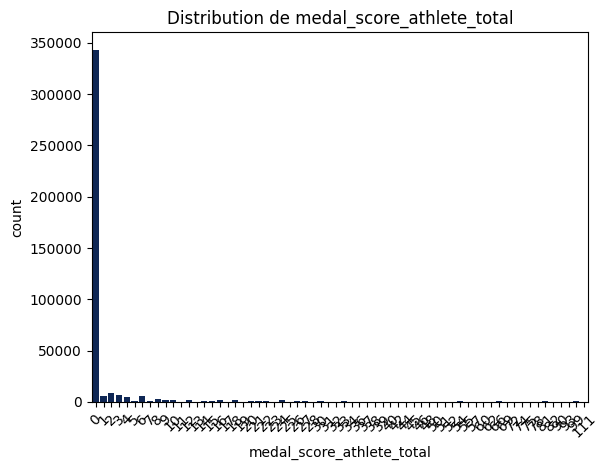

nb_medal_athlete
0     343019
1      15521
2       9912
3       5175
8       3751
6       3479
4       3162
5       2820
7       1501
33      1287
27      1269
10      1066
9        865
37       851
31       806
11       691
15       652
26       624
22       572
12       562
14       548
20       519
19       506
13       494
16       412
23       390
18       373
25       300
17       204
30       189
24        72
28        54
21        42
Name: count, dtype: int64


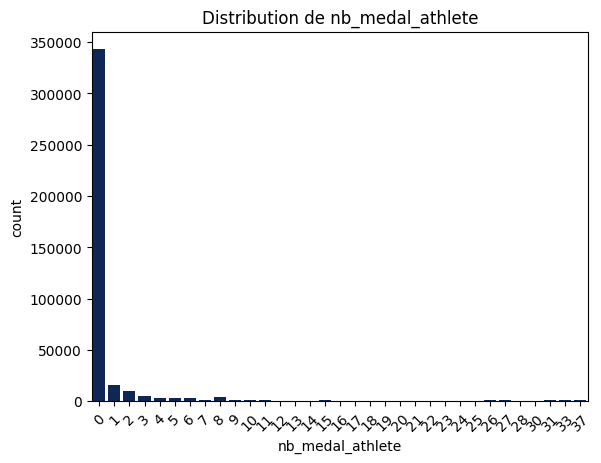

years_since_first
38     36732
30     35818
34     35206
26     31619
22     29784
54     28954
18     28621
10     27455
58     27065
14     26049
50     24282
62     24112
42     23485
46     19927
2       1675
6        408
102       95
78        70
70        65
74        59
66        47
90        33
98        33
118       27
120       22
94        20
106       17
114        5
130        3
Name: count, dtype: int64


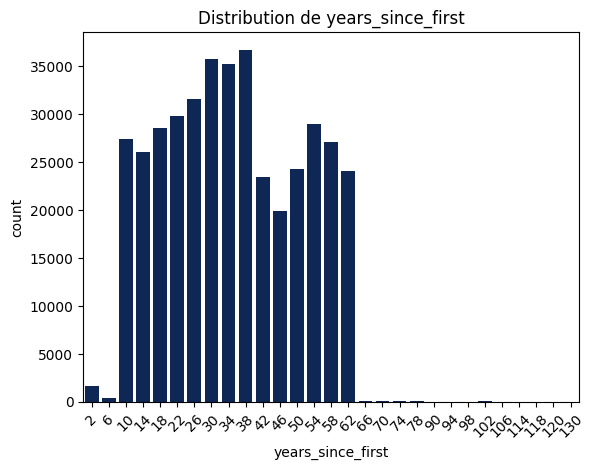

In [108]:
num_cols = df_clean[['Medal_score', 'Year',
       'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'years_since_first']]

for col in num_cols:
    print(df_clean[col].value_counts())
    sns.countplot(data=df_clean, x=col, color="#032361")
    plt.xticks(rotation=45)
    plt.title(f"Distribution de {col}")
    plt.show()

OBSERVATION : 
- Fin 1990 : explostion de la participation d'athlètes (pic 2020). 
- La majorité des athlètes ont participé entre 1 à 4 fois sur toute la période observée. 
- 1 équipe par athlète par année. 
- La majorité des athlètes ont un historique de 2 à 38 ans. 

In [98]:
df_clean.shape

(401688, 25)

In [99]:
df_clean.columns

Index(['NOC', 'Sport', 'Medal', 'host_NOC', 'Year', 'Age', 'Sex_encoded',
       'Medal_score', 'has_medal', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'evol_medal_athlete',
       'particip_pays', 'nb_sport_country', 'medal_score_country_total',
       'evol_medal_country', 'nb_athletes', 'nb_medals', 'medal_rate',
       'athlete_medal_ratio', 'is_host_country', 'years_since_first',
       'recent_athlete'],
      dtype='object')

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

In [109]:
num_cols = ['particip_pays', 'nb_sport_country', 'medal_score_country_total', 
            'nb_athletes', 'nb_medals', 'medal_rate', 'Age', 'particip_athlete']

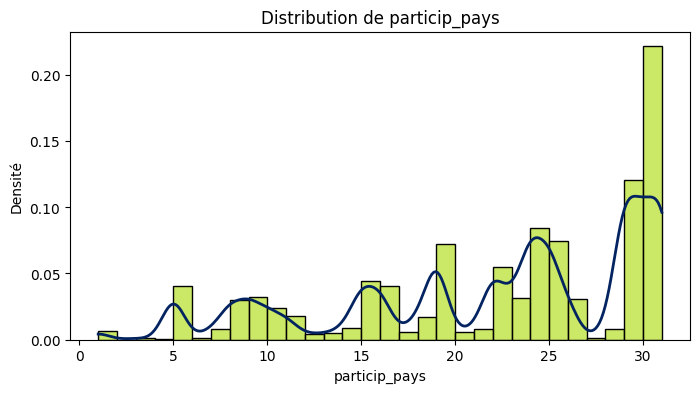

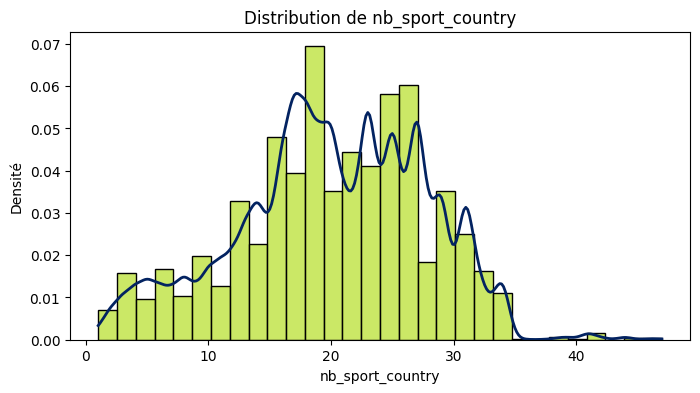

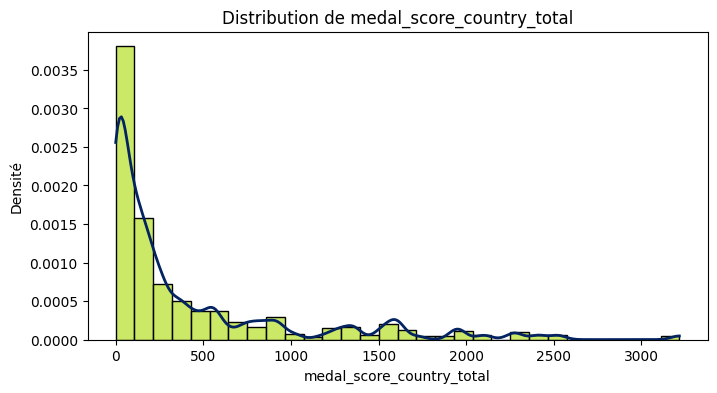

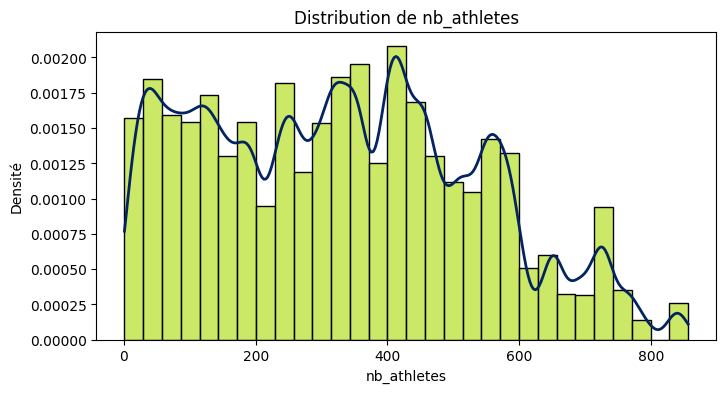

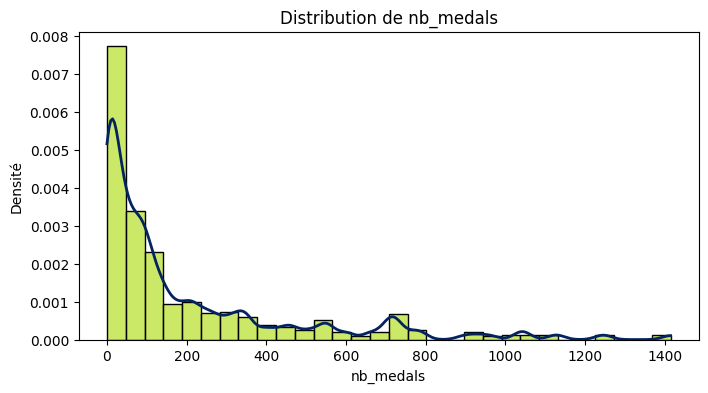

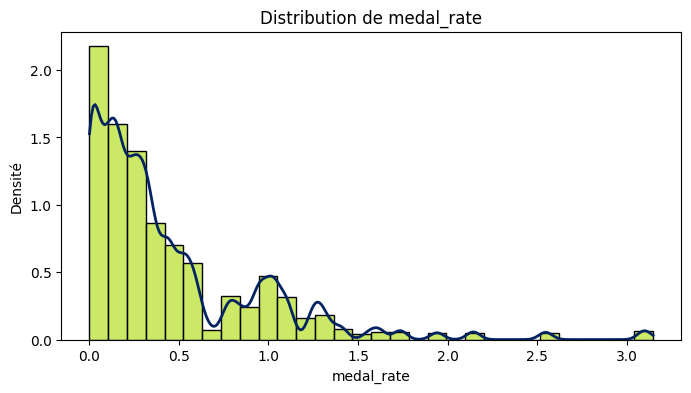

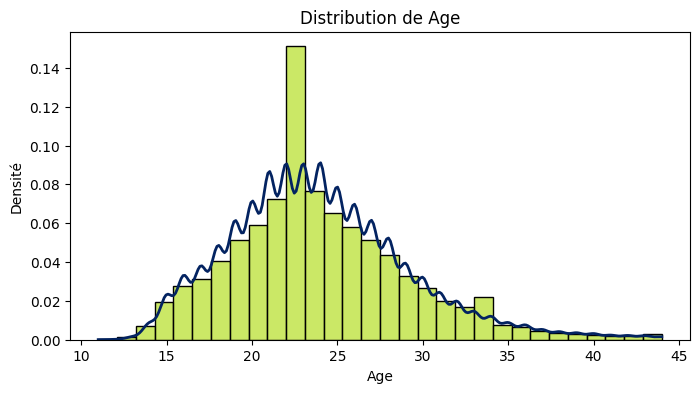

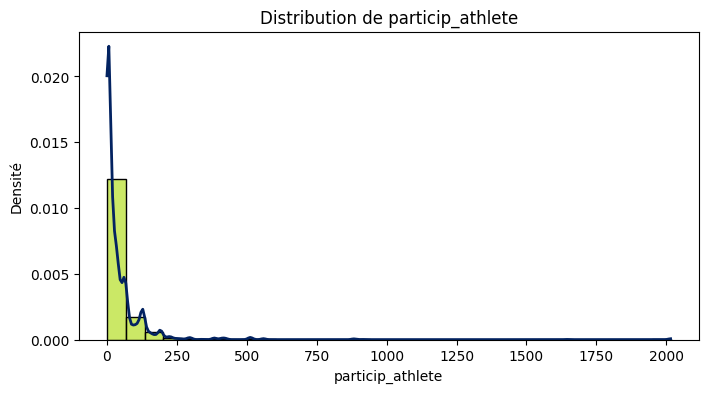

In [110]:
for col in num_cols:
    plt.figure(figsize=(8,4))

    # Histogramme vert
    sns.histplot(
        df_clean[col],
        color="#bae133",
        stat="density",
        bins=30
    )

    # KDE bleue (calculée manuellement)
    data = df_clean[col].dropna()
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 300)
    plt.plot(x_vals, kde(x_vals), color="#032361", linewidth=2)

    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Densité") # Plus la densité est haute, plus les valeurs sont fréquentes dans cette zone.
    plt.show()

OBSERVATION : 
- La majorité des pays ont participé au moins 20 fois à des JO. 
- La majorité des pays sont représentés par 15-20 sports par JO.
- La majorité des pays ont entre 0 & 15 médailles par JO. 
- Sur tout l'historique, la majoirté des pays a été représenté par jusqu'à 500 athlètes. 
- Majorité de la population a environ 23 ans.

---

### **ANALYSE BIVARIÉE**

##### Analyse des variables numériques avec la cible

In [ ]:
df_clean = df[['NOC','Sport', 'Medal', 'host_NOC', 'Year', 'Age', 'Sex_encoded', 
               'Medal_score', 'has_medal', 'particip_athlete', 'nb_team', 
               'medal_score_athlete_total', 'nb_medal_athlete', 
               'evol_medal_athlete', 'particip_pays', 'nb_sport_country', 
               'medal_score_country_total', 'evol_medal_country', 'nb_athletes', 
               'nb_medals', 'medal_rate', 'athlete_medal_ratio', 'is_host_country',
               'years_since_first', 'recent_athlete']]

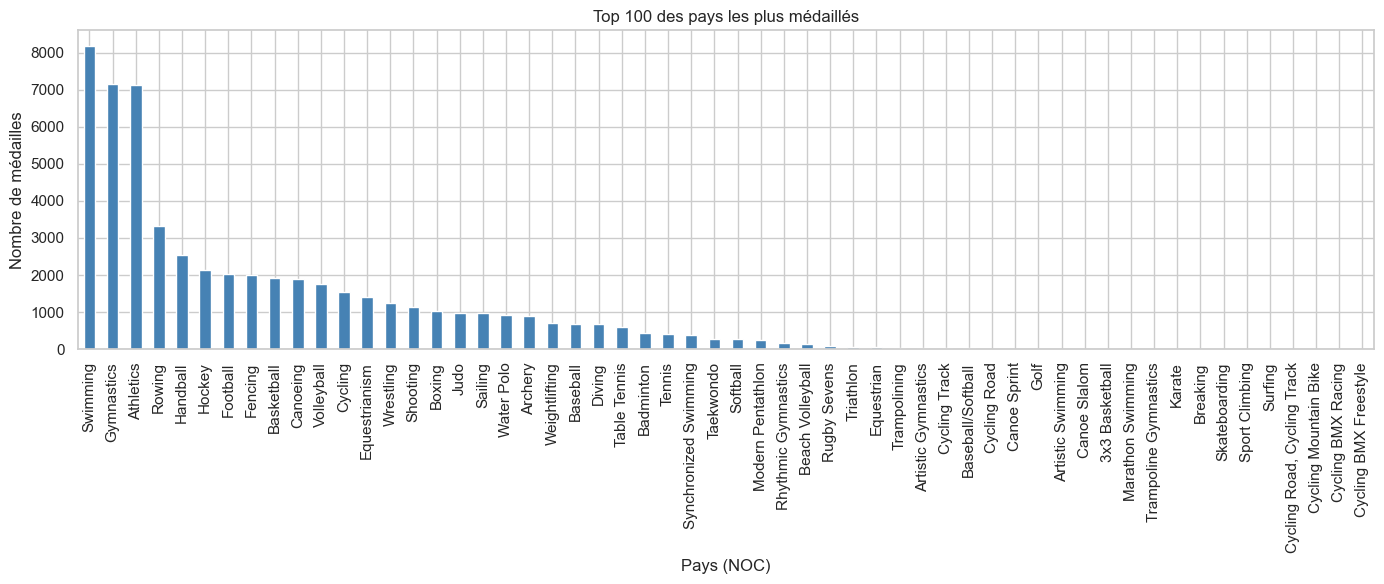

In [ ]:
# distribution globale des médailles par PAYS avec limitation des 100 premiers pays 

medals_by_country = (
    df_clean.groupby("Sport")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des pays les plus médaillés")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()

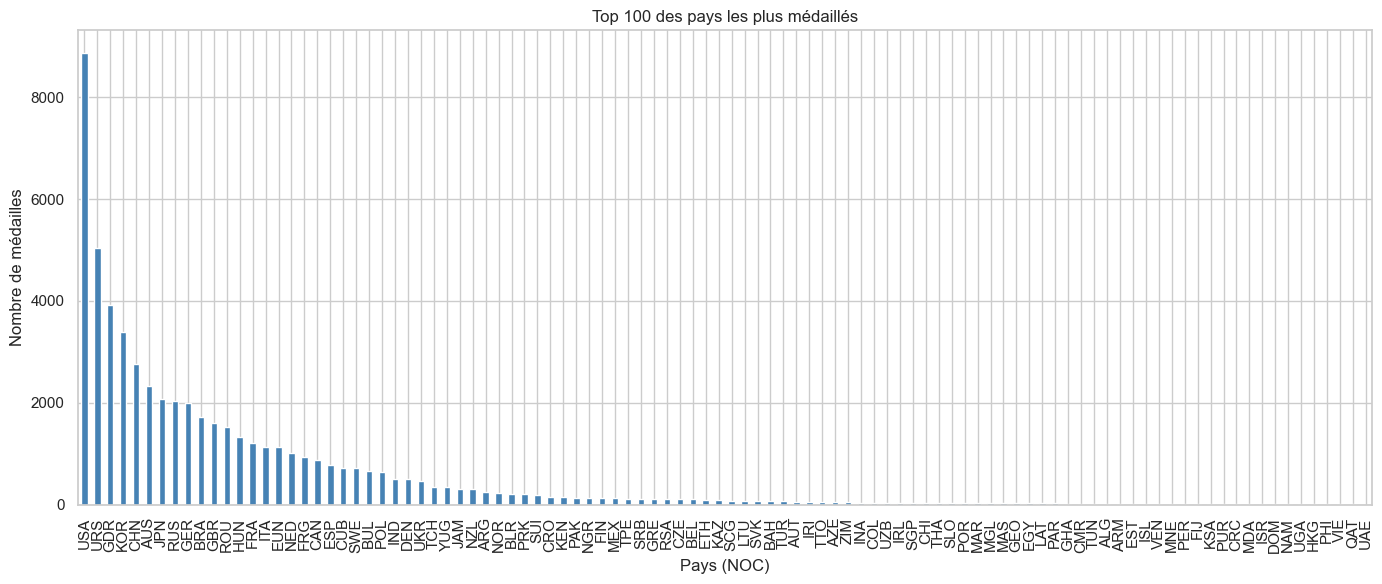

In [ ]:
# distribution globale des médailles par PAYS avec limitation des 100 premiers pays 

medals_by_country = (
    df.groupby("NOC")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des pays les plus médaillés")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()


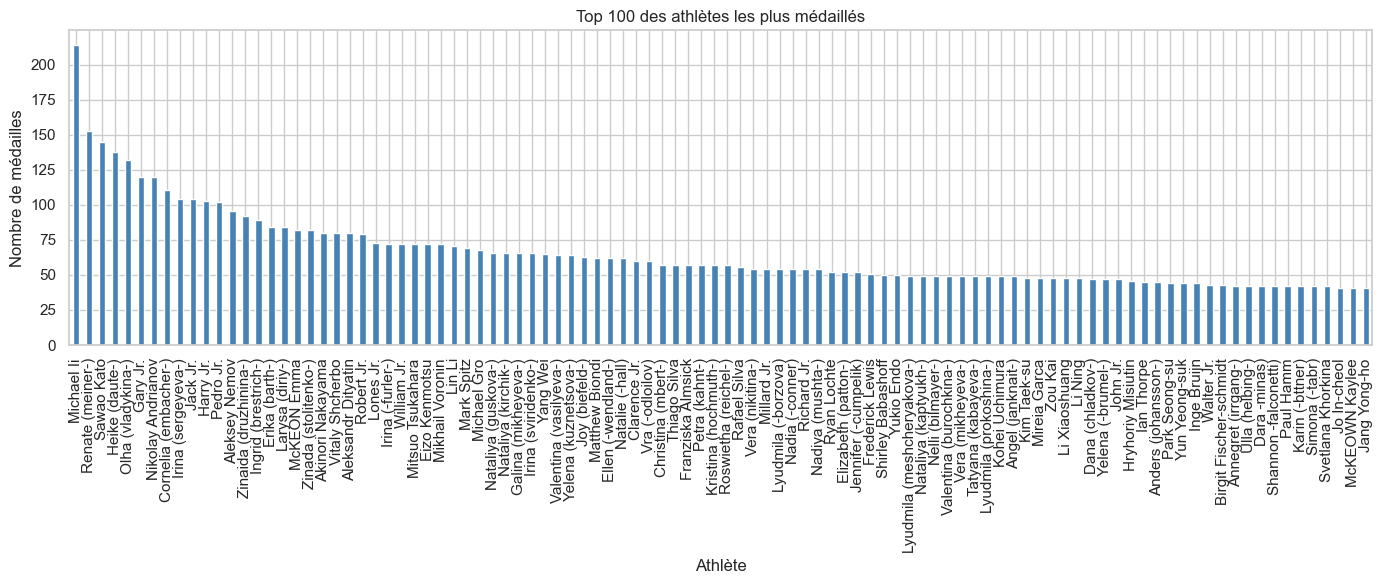

In [ ]:
# distribution globale des médailles par ATHLÈTE avec limitation des 100 premiers athlètes 

medals_by_country = (
    df.groupby("Name")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des athlètes les plus médaillés")
plt.xlabel("Athlète")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'clean_name', 'last_name', 'Age', 'Sex_encoded',
       'Medal_score', 'has_medal', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'evol_medal_athlete',
       'particip_pays', 'nb_athlete_country', 'nb_sport_country',
       'medal_score_country_total', 'nb_medal_country', 'evol_medal_country',
       'nb_athletes', 'nb_medals', 'medal_rate', 'athlete_medal_ratio',
       'host_NOC', 'is_host_country', 'first_year_athlete',
       'years_since_first', 'recent_athlete'],
      dtype='object')

In [ ]:
num_cols = df[['Sex_encoded', 'histo_athlete_years', 'particip_athlete', 'nb_team', 'particip_pays', 'nb_athlete_country', 'nb_sport_country', 'is_host_country', 'first_year_athlete', 'recent_athlete']].columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x="has_medal", y=col, data=df)

KeyError: "['histo_athlete_years'] not in index"

##### Correlation entre les variables numériques

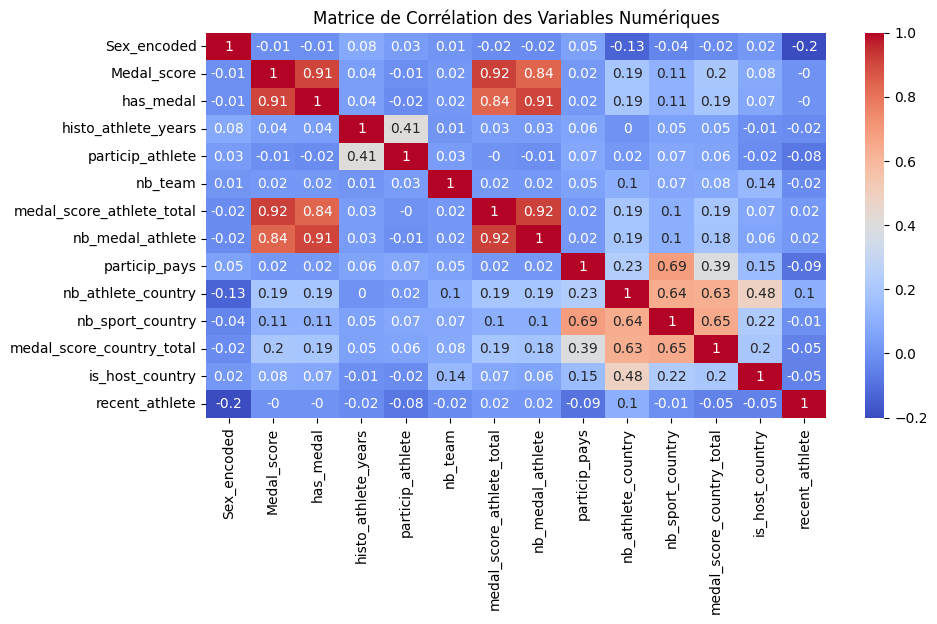

In [ ]:
num_cols = df[
    ['Sex_encoded', 'Medal_score', 'has_medal', 'histo_athlete_years', 'particip_athlete', 
    'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'recent_athlete']].columns


plt.figure(figsize=(10, 5))
corr = df[num_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()

##### Analyse des variables qualitatives avec la cible 

In [ ]:
df.groupby("Sport")["has_medal"].mean().sort_values(ascending=False)

Sport
Rugby                                  1.0
Cricket                                1.0
Basque Pelota                          1.0
Lacrosse                               1.0
Alpinism                               1.0
                                      ... 
Cycling Road, Cycling Mountain Bike    0.0
Cycling Road, Cycling Track            0.0
Marathon Swimming, Swimming            0.0
Cycling Road, Triathlon                0.0
3x3 Basketball, Basketball             0.0
Name: has_medal, Length: 76, dtype: float64

In [ ]:
df.groupby("NOC")["has_medal"].mean().sort_values(ascending=False)

NOC
URS    0.446344
GDR    0.400665
EUN    0.338462
ANZ    0.337209
USA    0.335102
         ...   
RHO    0.000000
GUM    0.000000
HON    0.000000
PNG    0.000000
LBA    0.000000
Name: has_medal, Length: 234, dtype: float64

In [ ]:
df.groupby("is_host_country")["has_medal"].mean()

is_host_country
0    0.146717
1    0.243147
Name: has_medal, dtype: float64

### **ANALYSE MULTIVARIÉE**

##### Variables numériques

In [ ]:
num_cols = df[
    ['Sex_encoded', 'Medal_score', 'has_medal', 'histo_athlete_years', 'particip_athlete', 
    'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'recent_athlete']].columns


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df[num_cols].fillna(0)
y = df["has_medal"]

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

has_medal                    0.473519
Medal_score                  0.261640
medal_score_athlete_total    0.131291
nb_medal_athlete             0.124410
medal_score_country_total    0.004323
nb_athlete_country           0.002434
nb_sport_country             0.001477
histo_athlete_years          0.000326
particip_pays                0.000253
is_host_country              0.000117
particip_athlete             0.000108
recent_athlete               0.000069
Sex_encoded                  0.000023
nb_team                      0.000010
dtype: float64

##### Variables qualitatives

In [ ]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'Sex_encoded', 'Medal_score', 'has_medal',
       'histo_athlete_years', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'host_NOC', 'host_city', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [ ]:
quali_cols = ['NOC', 'Sport', 'Team', 'City', 'Event', 'host_NOC', 'host_city']

from scipy.stats import chi2_contingency

for col in quali_cols:
    contingency = pd.crosstab(df[col], df["has_medal"])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"{col} : p-value = {p}")

NOC : p-value = 0.0
Sport : p-value = 0.0
Team : p-value = 0.0
City : p-value = 0.0
Event : p-value = 0.0
host_NOC : p-value = 0.0
host_city : p-value = 0.0


##### Interaction entre variables

In [ ]:
df["athlete_strength"] = df["nb_medal_athlete"] * df["particip_athlete"]
df["country_strength"] = df["nb_athlete_country"] * df["nb_sport_country"]

### **CONSTRUCTION DU MODÈLE DE MACHINE LEARNING**

##### Préparation des données

In [ ]:
df["athlete_career_length"] = df.groupby("Name")["Year"].transform(lambda x: x.max() - x.min())

In [ ]:
y = df["has_medal"]

##### Features

In [ ]:
features = [
    # athlete
    "particip_athlete",
    "nb_medal_athlete",
    "nb_team",
    "athlete_strength",
    "athlete_career_length",

    # country
    "nb_athlete_country",
    "nb_sport_country",
    "particip_pays",
    "country_strength",

    # contexte
    "is_host_country",
    "Sex_encoded"
]

##### Dataset final

In [ ]:
X = df[features].fillna(0)

##### TRAIN / TEST SPLIT (TEMPOREL)

In [ ]:
train = df[df["Year"] <= 2016]
test  = df[df["Year"] > 2016]

X_train = train[features].fillna(0)
y_train = train["has_medal"]

X_test = test[features].fillna(0)
y_test = test["has_medal"]

##### GESTION DU DÉSÉQUILIBRE

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

##### MODÈLE PRINCIPAL (XGBoost recommandé)

In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import xgboost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=class_weights[1],
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

##### ÉVALUATION

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_proba = model.predict_proba(X_test)[:,1]

threshold = 0.75
y_pred = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     25283
           1       0.70      0.99      0.82      4730

    accuracy                           0.93     30013
   macro avg       0.85      0.95      0.89     30013
weighted avg       0.95      0.93      0.94     30013

ROC AUC: 0.9679600955241633


##### FEATURE IMPORTANCE

In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False)

nb_medal_athlete         0.821647
athlete_strength         0.173817
nb_sport_country         0.000740
particip_pays            0.000737
nb_athlete_country       0.000665
country_strength         0.000630
athlete_career_length    0.000481
particip_athlete         0.000436
is_host_country          0.000328
Sex_encoded              0.000305
nb_team                  0.000215
dtype: float32

##### PRÉDICTION JO28

In [ ]:
df["medal_proba"] = model.predict_proba(X)[:,1]

##### TOP PAYS 

In [ ]:
country_rank = (
    df_rank.groupby("NOC")["medal_proba"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_rank.head(10)

NameError: name 'df_rank' is not defined

##### TOP ATHLÈTES

In [ ]:
df_rank = df.copy()

df_rank["medal_proba"] = model.predict_proba(X)[:,1]

top_athletes = df_rank.sort_values("medal_proba", ascending=False)

top_athletes[["Name", "Sport", "NOC", "medal_proba"]].head(20)

,Name,Sport,NOC,medal_proba
246966,Abbey Weitzeil,Swimming,USA,0.999897
246967,Abbey Weitzeil,Swimming,USA,0.999897
246968,Abbey Weitzeil,Swimming,USA,0.999897
229868,Kathleen Ledecky,Swimming,USA,0.999881
247042,Simone Manuel,Swimming,USA,0.999859
247043,Simone Manuel,Swimming,USA,0.999859
247041,Simone Manuel,Swimming,USA,0.999859
230665,Simone Manuel,Swimming,USA,0.999859
247060,Regan Smith,Swimming,USA,0.999854
247061,Regan Smith,Swimming,USA,0.999854


##### TOP SPORTS

In [ ]:
sport_rank = (
    df_rank.groupby("Sport")["medal_proba"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sport_rank.head(10)

,Sport,medal_proba
0,Cricket,0.994710
1,Lacrosse,0.993423
2,Rugby,0.989370
3,Alpinism,0.988085
4,Aeronautics,0.988050
5,Basque Pelota,0.979472
6,Racquets,0.826857
7,Roque,0.747911
8,Polo,0.693916
9,Tug-Of-War,0.670034


##### Score composite 

In [ ]:
df_rank["jo_score"] = (
    df_rank["medal_proba"] * 0.7 +
    df_rank["nb_medal_athlete"] * 0.2 +
    df_rank["particip_athlete"] * 0.1
)

---

### **PRÉPARATION DASHBOARD**

In [ ]:
df_dashboard = df[[
    "Name",
    "NOC",
    "Sport",
    "medal_proba"
]]

df_dashboard.to_csv("predictions_JO28.csv", index=False)

##### Feature engineering avancé

In [ ]:
df["athlete_strength"] = df["nb_medal_athlete"] * df["particip_athlete"]
df["country_strength"] = df["nb_athlete_country"] * df["nb_sport_country"]

##### Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

---

### **CRÉATION ET MISE EN PLACE DU DASHBOARD**

##### CRÉATION

In [ ]:
import streamlit as st
import pandas as pd
import joblib

# ======================
# CONFIG
# ======================
st.set_page_config(page_title="JO28 Dashboard", layout="wide")

st.title("🏅 JO 2028 - Prediction Dashboard")

# ======================
# LOAD DATA + MODEL
# ======================
df = pd.read_csv("predictions_JO28.csv")

# Si tu sauvegardes ton modèle :
# model = joblib.load("model.pkl")

# ======================
# FEATURES (doivent matcher ton modèle)
# ======================
features = [
    "particip_athlete",
    "nb_medal_athlete",
    "nb_team",
    "nb_athlete_country",
    "nb_sport_country",
    "particip_pays",
    "is_host_country",
    "Sex_encoded",
    "athlete_career_length"
]

df["medal_proba"]

# ======================
# SIDEBAR FILTERS
# ======================
st.sidebar.header("🎛️ Filtres")

countries = st.sidebar.multiselect(
    "🌍 Pays",
    df["NOC"].unique()
)

sports = st.sidebar.multiselect(
    "🏅 Sports",
    df["Sport"].unique()
)

threshold = st.sidebar.slider(
    "🎯 Seuil de médaille",
    0.0, 1.0, 0.7, 0.01
)

# ======================
# FILTER DATA
# ======================
filtered_df = df.copy()

if countries:
    filtered_df = filtered_df[filtered_df["NOC"].isin(countries)]

if sports:
    filtered_df = filtered_df[filtered_df["Sport"].isin(sports)]

filtered_df["prediction"] = (filtered_df["medal_proba"] > threshold).astype(int)

# ======================
# KPIs
# ======================
st.subheader("📊 Indicateurs clés")

col1, col2, col3 = st.columns(3)

col1.metric("Athlètes", len(filtered_df))
col2.metric("Médaillés prédits", filtered_df["prediction"].sum())
col3.metric("Proba moyenne", round(filtered_df["medal_proba"].mean(), 3))

# ======================
# TOP ATHLÈTES
# ======================
st.subheader("🥇 Top Athlètes")

top_athletes = filtered_df.sort_values("medal_proba", ascending=False)

st.dataframe(
    top_athletes[["Name", "NOC", "Sport", "medal_proba", "prediction"]].head(20)
)

# ======================
# TOP PAYS
# ======================
st.subheader("🌍 Classement des pays")

country_rank = (
    filtered_df.groupby("NOC")["medal_proba"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

st.bar_chart(country_rank.set_index("NOC"))

# ======================
# TOP SPORTS
# ======================
st.subheader("🏅 Classement des sports")

sport_rank = (
    filtered_df.groupby("Sport")["medal_proba"]
    .mean()
    .sort_values(ascending=False)
)

st.bar_chart(sport_rank)

# ======================
# TABLE DÉTAILLÉE
# ======================
st.subheader("📋 Analyse détaillée")

st.dataframe(
    filtered_df.sort_values("medal_proba", ascending=False)[
        ["Name", "NOC", "Sport", "medal_proba", "prediction"]
    ]
)

DeltaGenerator()

##### LANCEMENT